In [37]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

In [38]:
dataset = pd.read_csv("/content/Housing.csv")

In [39]:
dataset.head(3)

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,yes,no,no,no,yes,2,yes,furnished
1,12250000,8960,4,4,4,yes,no,no,no,yes,3,no,furnished
2,12250000,9960,3,2,2,yes,no,yes,no,no,2,yes,semi-furnished


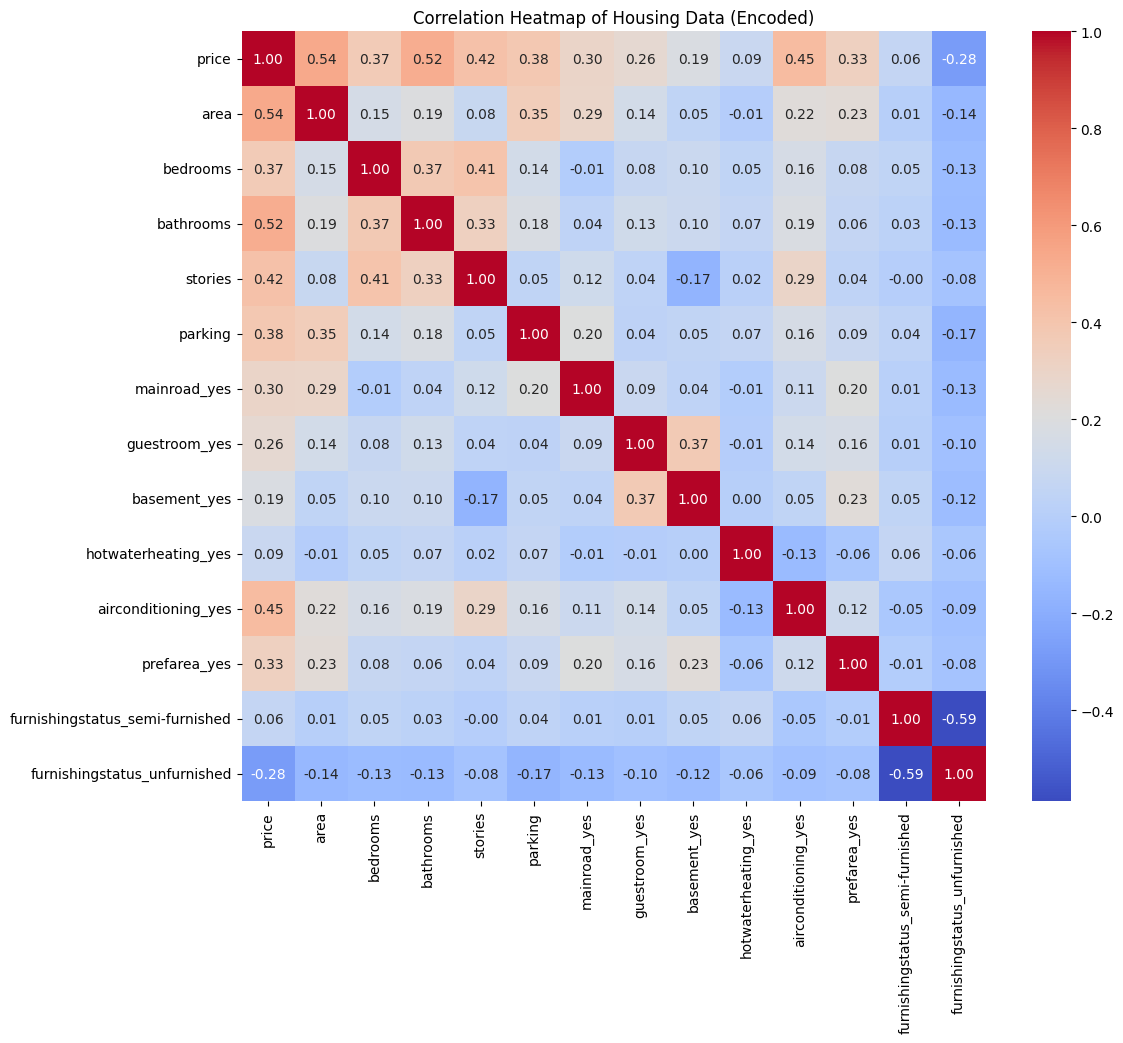

In [44]:
plt.figure(figsize=(12, 10))
sns.heatmap(data=dataset_encoded.corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Heatmap of Housing Data (Encoded)')
plt.show()

In [43]:
# Select categorical columns to encode
categorical_cols = ['mainroad', 'guestroom', 'basement', 'hotwaterheating', 'airconditioning', 'prefarea', 'furnishingstatus']

# Apply one-hot encoding
dataset_encoded = pd.get_dummies(dataset, columns=categorical_cols, drop_first=True)

display(dataset_encoded.head())

,price,area,bedrooms,bathrooms,stories,parking,mainroad_yes,guestroom_yes,basement_yes,hotwaterheating_yes,airconditioning_yes,prefarea_yes,furnishingstatus_semi-furnished,furnishingstatus_unfurnished
0,13300000,7420,4,2,3,2,True,False,False,False,True,True,False,False
1,12250000,8960,4,4,4,3,True,False,False,False,True,False,False,False
2,12250000,9960,3,2,2,2,True,False,True,False,False,True,True,False
3,12215000,7500,4,2,2,3,True,False,True,False,True,True,False,False
4,11410000,7420,4,1,2,2,True,True,True,False,True,False,False,False


In [46]:
x = dataset.iloc[:,:-1]
y = dataset["price"]

In [51]:
sc = StandardScaler()
x_scaled = sc.fit_transform(dataset_encoded.drop('price', axis=1))
x_scaled_df = pd.DataFrame(x_scaled, columns=dataset_encoded.drop('price', axis=1).columns)
display(x_scaled_df.head())

,area,bedrooms,bathrooms,stories,parking,mainroad_yes,guestroom_yes,basement_yes,hotwaterheating_yes,airconditioning_yes,prefarea_yes,furnishingstatus_semi-furnished,furnishingstatus_unfurnished
0,1.046726,1.403419,1.421812,1.378217,1.517692,0.405623,-0.465315,-0.734539,-0.219265,1.472618,1.804941,-0.844888,-0.696429
1,1.757010,1.403419,5.405809,2.532024,2.679409,0.405623,-0.465315,-0.734539,-0.219265,1.472618,-0.554035,-0.844888,-0.696429
2,2.218232,0.047278,1.421812,0.224410,1.517692,0.405623,-0.465315,1.361397,-0.219265,-0.679063,1.804941,1.183588,-0.696429
3,1.083624,1.403419,1.421812,0.224410,2.679409,0.405623,-0.465315,1.361397,-0.219265,1.472618,1.804941,-0.844888,-0.696429
4,1.046726,1.403419,-0.570187,0.224410,1.517692,0.405623,2.149083,1.361397,-0.219265,1.472618,-0.554035,-0.844888,-0.696429


In [ ]:
sc = StandardScaler()
x_scaled = sc.fit_transform(dataset_encoded.drop('price', axis=1))
x_scaled_df = pd.DataFrame(x_scaled, columns=dataset_encoded.drop('price', axis=1).columns)
display(x_scaled_df.head())

In [55]:
x_train , x_test , y_train , y_test = train_test_split(x_scaled_df,y,test_size=0.2,random_state=42)

In [53]:
from sklearn.linear_model import LinearRegression , Lasso ,Ridge

In [80]:
from sklearn.metrics import mean_absolute_error , mean_squared_error
import numpy as np

LinearRegression


In [58]:
lr = LinearRegression()
lr.fit(x_train,y_train)
lr.score(x_test,y_test)*100

65.29242642153177

In [84]:
print(mean_squared_error(y_test,lr.predict(x_test)))
print(mean_absolute_error(y_test,lr.predict(x_test)))
print(np.sqrt(mean_squared_error(y_test,lr.predict(x_test))))

1754318687330.6675
970043.4039201641
1324506.96009144


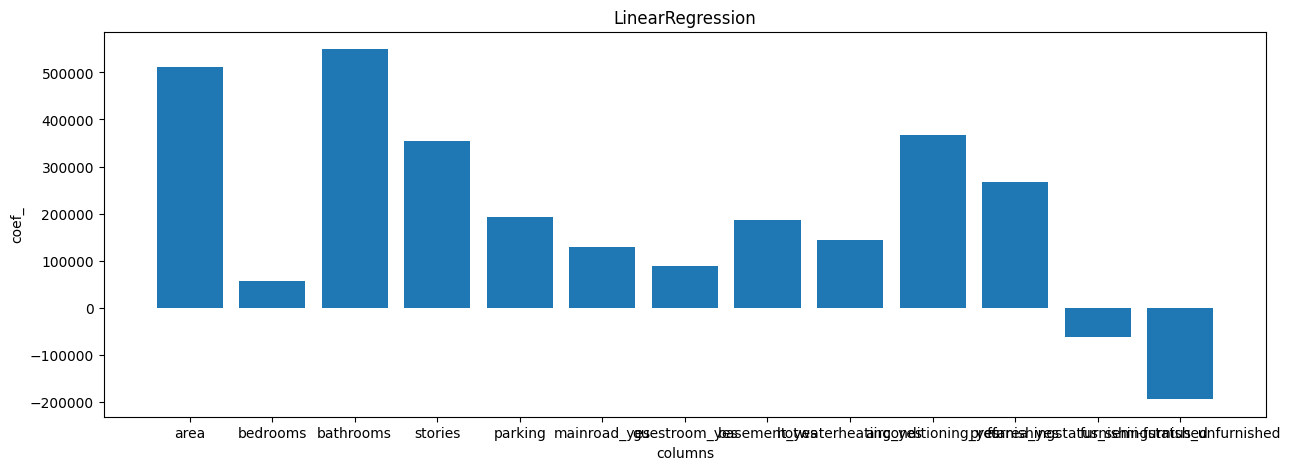

In [69]:
plt.figure(figsize=(15,5))
plt.bar(x_scaled_df.columns,lr.coef_)
plt.title("LinearRegression")
plt.xlabel("columns")
plt.ylabel("coef_")
plt.show()

In [67]:
# Get feature names from the scaled data
feature_names = x_scaled_df.columns

# Get the linear regression coefficients
coefficients = lr.coef_

# Create a pandas Series to display coefficients with feature names
coefficients_series = pd.Series(coefficients, index=feature_names)

# Display the coefficients and feature names
display(coefficients_series)

,0
area,511615.563777
bedrooms,56615.572458
bathrooms,549420.501241
stories,353158.429856
parking,193542.781675
mainroad_yes,128151.921295
guestroom_yes,88590.213462
basement_yes,186194.150506
hotwaterheating_yes,143233.206250
airconditioning_yes,367817.894916


In [59]:
lr.coef_

array([ 511615.56377666,   56615.57245779,  549420.50124098,
        353158.42985604,  193542.78167455,  128151.92129533,
         88590.21346152,  186194.15050566,  143233.20624958,
        367817.89491558,  267018.66081239,  -62550.29721128,
       -193987.7810882 ])

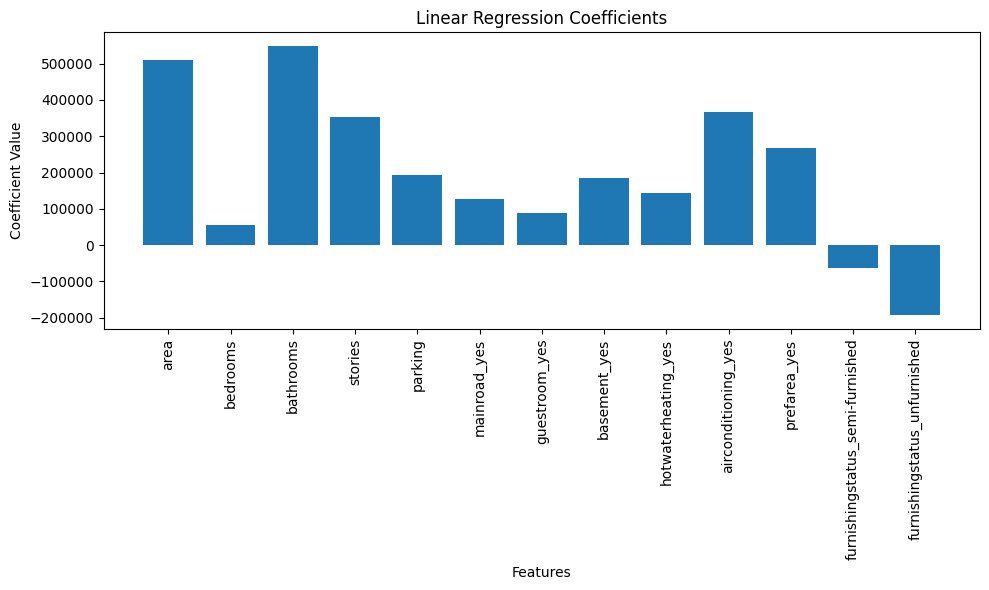

In [61]:
# Get feature names and coefficients
feature_names = x_scaled_df.columns
coefficients = lr.coef_

# Create a bar plot of coefficients
plt.figure(figsize=(10, 6))
plt.bar(feature_names, coefficients)
plt.xticks(rotation=90)
plt.xlabel("Features")
plt.ylabel("Coefficient Value")
plt.title("Linear Regression Coefficients")
plt.tight_layout()
plt.show()

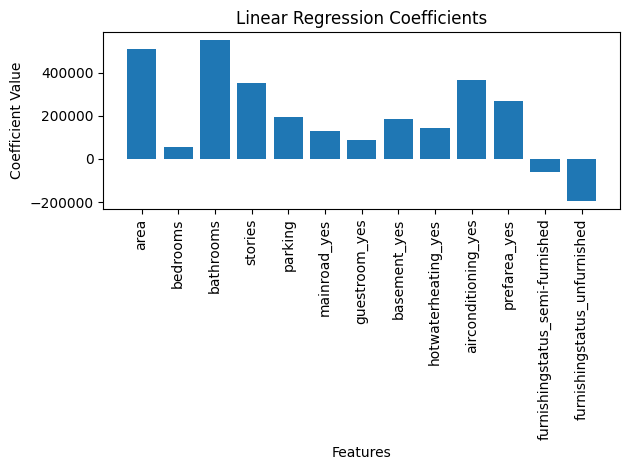

In [64]:
plt.bar(x_scaled_df.columns,lr.coef_)
plt.xticks(rotation=90)
plt.xlabel("Features")
plt.ylabel("Coefficient Value")
plt.title("Linear Regression Coefficients")
plt.tight_layout()
plt.show()

In [62]:
x.columns

Index(['price', 'area', 'bedrooms', 'bathrooms', 'stories', 'mainroad',
       'guestroom', 'basement', 'hotwaterheating', 'airconditioning',
       'parking', 'prefarea'],
      dtype='object')

Lasso

In [74]:
la = Lasso(alpha=0.01)
la.fit(x_train,y_train)
la.score(x_test,y_test)*100

65.29242616915083

In [86]:
print(mean_squared_error(y_test,la.predict(x_test)))
print(mean_absolute_error(y_test,la.predict(x_test)))
print(np.sqrt(mean_squared_error(y_test,lr.predict(x_test))))

1754318700087.439
970043.4037605525
1324506.96009144


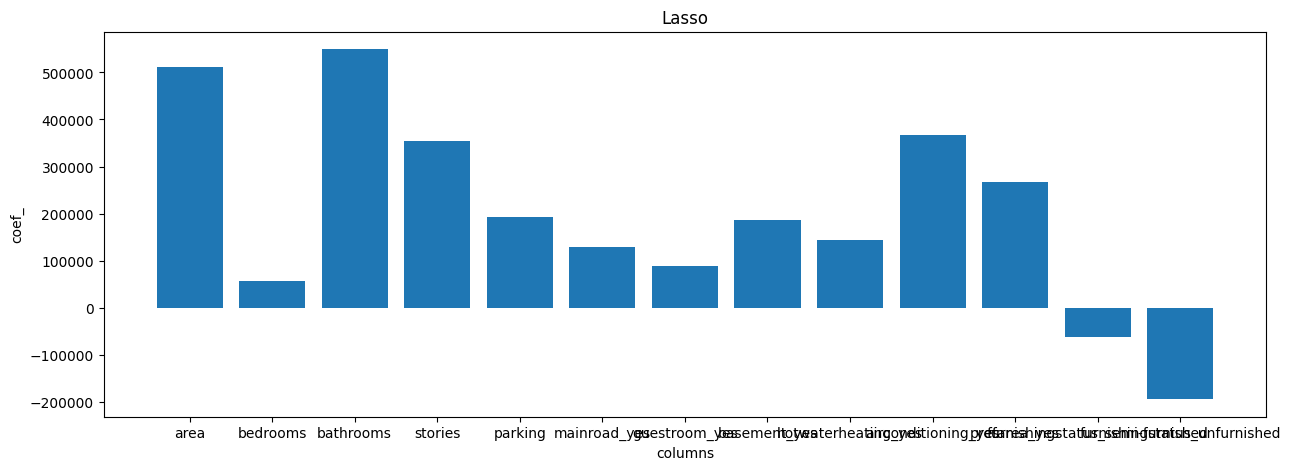

In [75]:
plt.figure(figsize=(15,5))
plt.bar(x_scaled_df.columns,la.coef_)
plt.title("Lasso")
plt.xlabel("columns")
plt.ylabel("coef_")
plt.show()

Ridge

In [77]:
ri = Ridge(alpha = 10)
ri.fit(x_train,y_train)
ri.score(x_test,y_test)*100

65.19079253215372

In [87]:
print(mean_squared_error(y_test,ri.predict(x_test)))
print(mean_absolute_error(y_test,ri.predict(x_test)))
print(np.sqrt(mean_squared_error(y_test,ri.predict(x_test))))

1759455843663.3882
967942.6216085084
1326444.8136516605


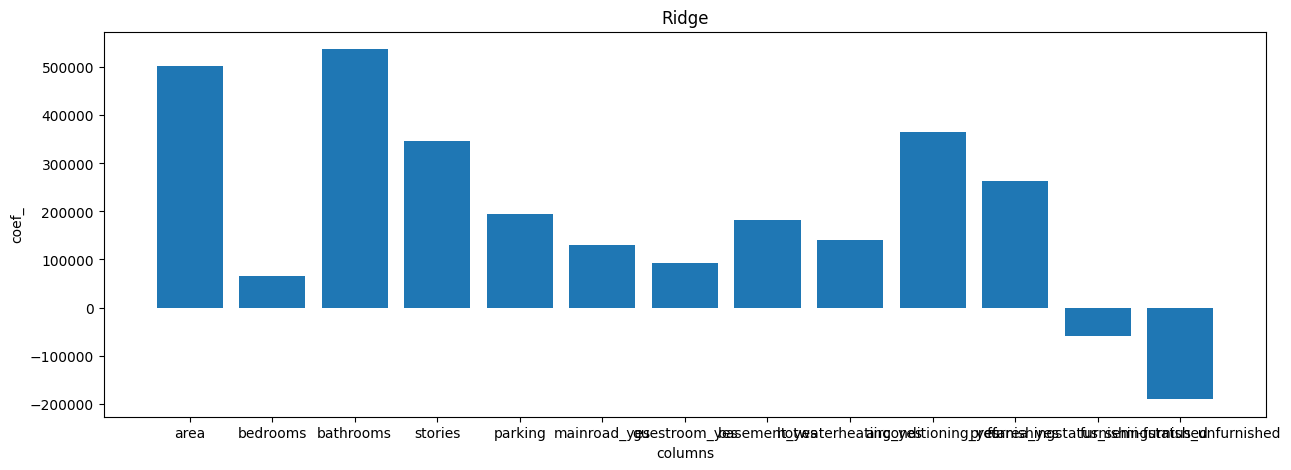

In [79]:
plt.figure(figsize=(15,5))
plt.bar(x_scaled_df.columns,ri.coef_)
plt.title("Ridge")
plt.xlabel("columns")
plt.ylabel("coef_")
plt.show()

In [89]:
df = pd.DataFrame({"col_name":x_scaled_df.columns,"LinearRegression":lr.coef_,"Lasso":la.coef_,"Ridge":ri.coef_})

In [90]:
df

,col_name,LinearRegression,Lasso,Ridge
0,area,511615.563777,511615.561850,502252.286215
1,bedrooms,56615.572458,56615.569851,65132.373585
2,bathrooms,549420.501241,549420.497667,537574.041615
3,stories,353158.429856,353158.424955,346006.857732
4,parking,193542.781675,193542.778426,194954.682792
5,mainroad_yes,128151.921295,128151.917762,130790.775299
6,guestroom_yes,88590.213462,88590.209813,91998.609421
7,basement_yes,186194.150506,186194.144955,181385.995261
8,hotwaterheating_yes,143233.206250,143233.196983,140133.580908
9,airconditioning_yes,367817.894916,367817.892499,364207.282689
